In [1]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

from cgm_ics.latexify import latexify
from cgm_ics import solve_ode as CF
from cgm_ics import halo_potentials as Halo
from cgm_ics import cooling_functions as Cool

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

import importlib # for testing : importlib.reload(module)

import pickle
from pathlib import Path

In [2]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

print(cosmo)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)


In [3]:
# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

In [4]:
# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82

print(c_vir)
      
print("Halo Mass: ",np.log10(M_vir.value))
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)
miyamoto = Halo.MiyamotoNagaiPotential(M_gal, r_gal, z_gal)

print("NFW Scale Density: ", nfw.rho_s)

10.54718269190388
Halo Mass:  11.0
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc
NFW Scale Density:  3320989.038326563 solMass / kpc3


In [5]:
# Set Units
cu_length  = 3.0856775809623245e+21 * un.cm # kpc
cu_mass    = 3.036951775493658e+39 * un. g  # number density 0.1 cm^-3 when box size is 1 kpc
cu_time    = 3.15576e+15  * un.s            # 100 Myr

# Derived Units
cu_velocity = cu_length/cu_time # cm/s
cu_density = cu_mass/cu_length**3 # g/cm**3
cu_energy = cu_mass*cu_velocity**2 # erg
cu_pressure = cu_energy/cu_length**3 # erg/cm**3 or dyne/cm^2
cu_temperature = cu_velocity**2*mu*cons.m_p/cons.k_B # K

print(cu_velocity.to('km/s'))
print(cu_density.to('g/cm3'))
print(cu_temperature.to('K'))

9.777922215131456 km / s
1.0336803493720967e-25 g / cm3
7181.238455976716 K


In [6]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1.0/3,z=0)

In [7]:
r_ref = np.logspace(np.log10(0.01), np.log10(300), 500) * un.kpc
t_ff = (2**0.5 * r_ref / combined.vc(r_ref)).to('Gyr')
v_circ = combined.vc(r_ref).to('km/s')

In [12]:
combined2 = Halo.CombinedPotential_using_modified_plummer(M_vir, r_vir, c_vir, M_gal, z_gal, r_gal, rho_mean, r_200_m)

# Generate CGM steady-state cooling flow solution
max_step = 0.01                          # lowest resolution of solution in ln(r)
R_min    = 0.01*un.kpc                      # inner radius of supersonic part of solution
R_max    = 50*un.kpc                    # outer radius of integration
R_sonic  = 0.06*un.kpc              # sonic radii

print('R_sonic = %s'%R_sonic)
sol2 = CF.shoot_from_R_sonic(combined2,cooling,R_sonic,R_max,R_min,max_step=max_step,verbose=True)
print('Mass Flow Rate: ', sol2.mass_flow_rate)

R_sonic = 0.06 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Sonic point (Maximum r = 0 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.500015 ... Stop reason: Sonic point (Maximum r = 0 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.250018 ... Stop reason: Sonic point (Maximum r = 12 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.125019 ... Stop reason: Unbound (Maximum r = 0 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.187518 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.218768 ... Stop reason: Unbound (Maximum r = 7 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.234393 ... Stop reason: Max R reached (Maximum r = 49 kpc)
Inward integration of supersonic part reached r = 0.010 kpc
Mass Flow Rate:  0.0007781604116619057 solMass / yr


/tmp/ipykernel_361859/2863655130.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0, 1].legend(frameon=True, loc='upper right', title=r'R$_{\rm sonic}$', handlelength=1.8)


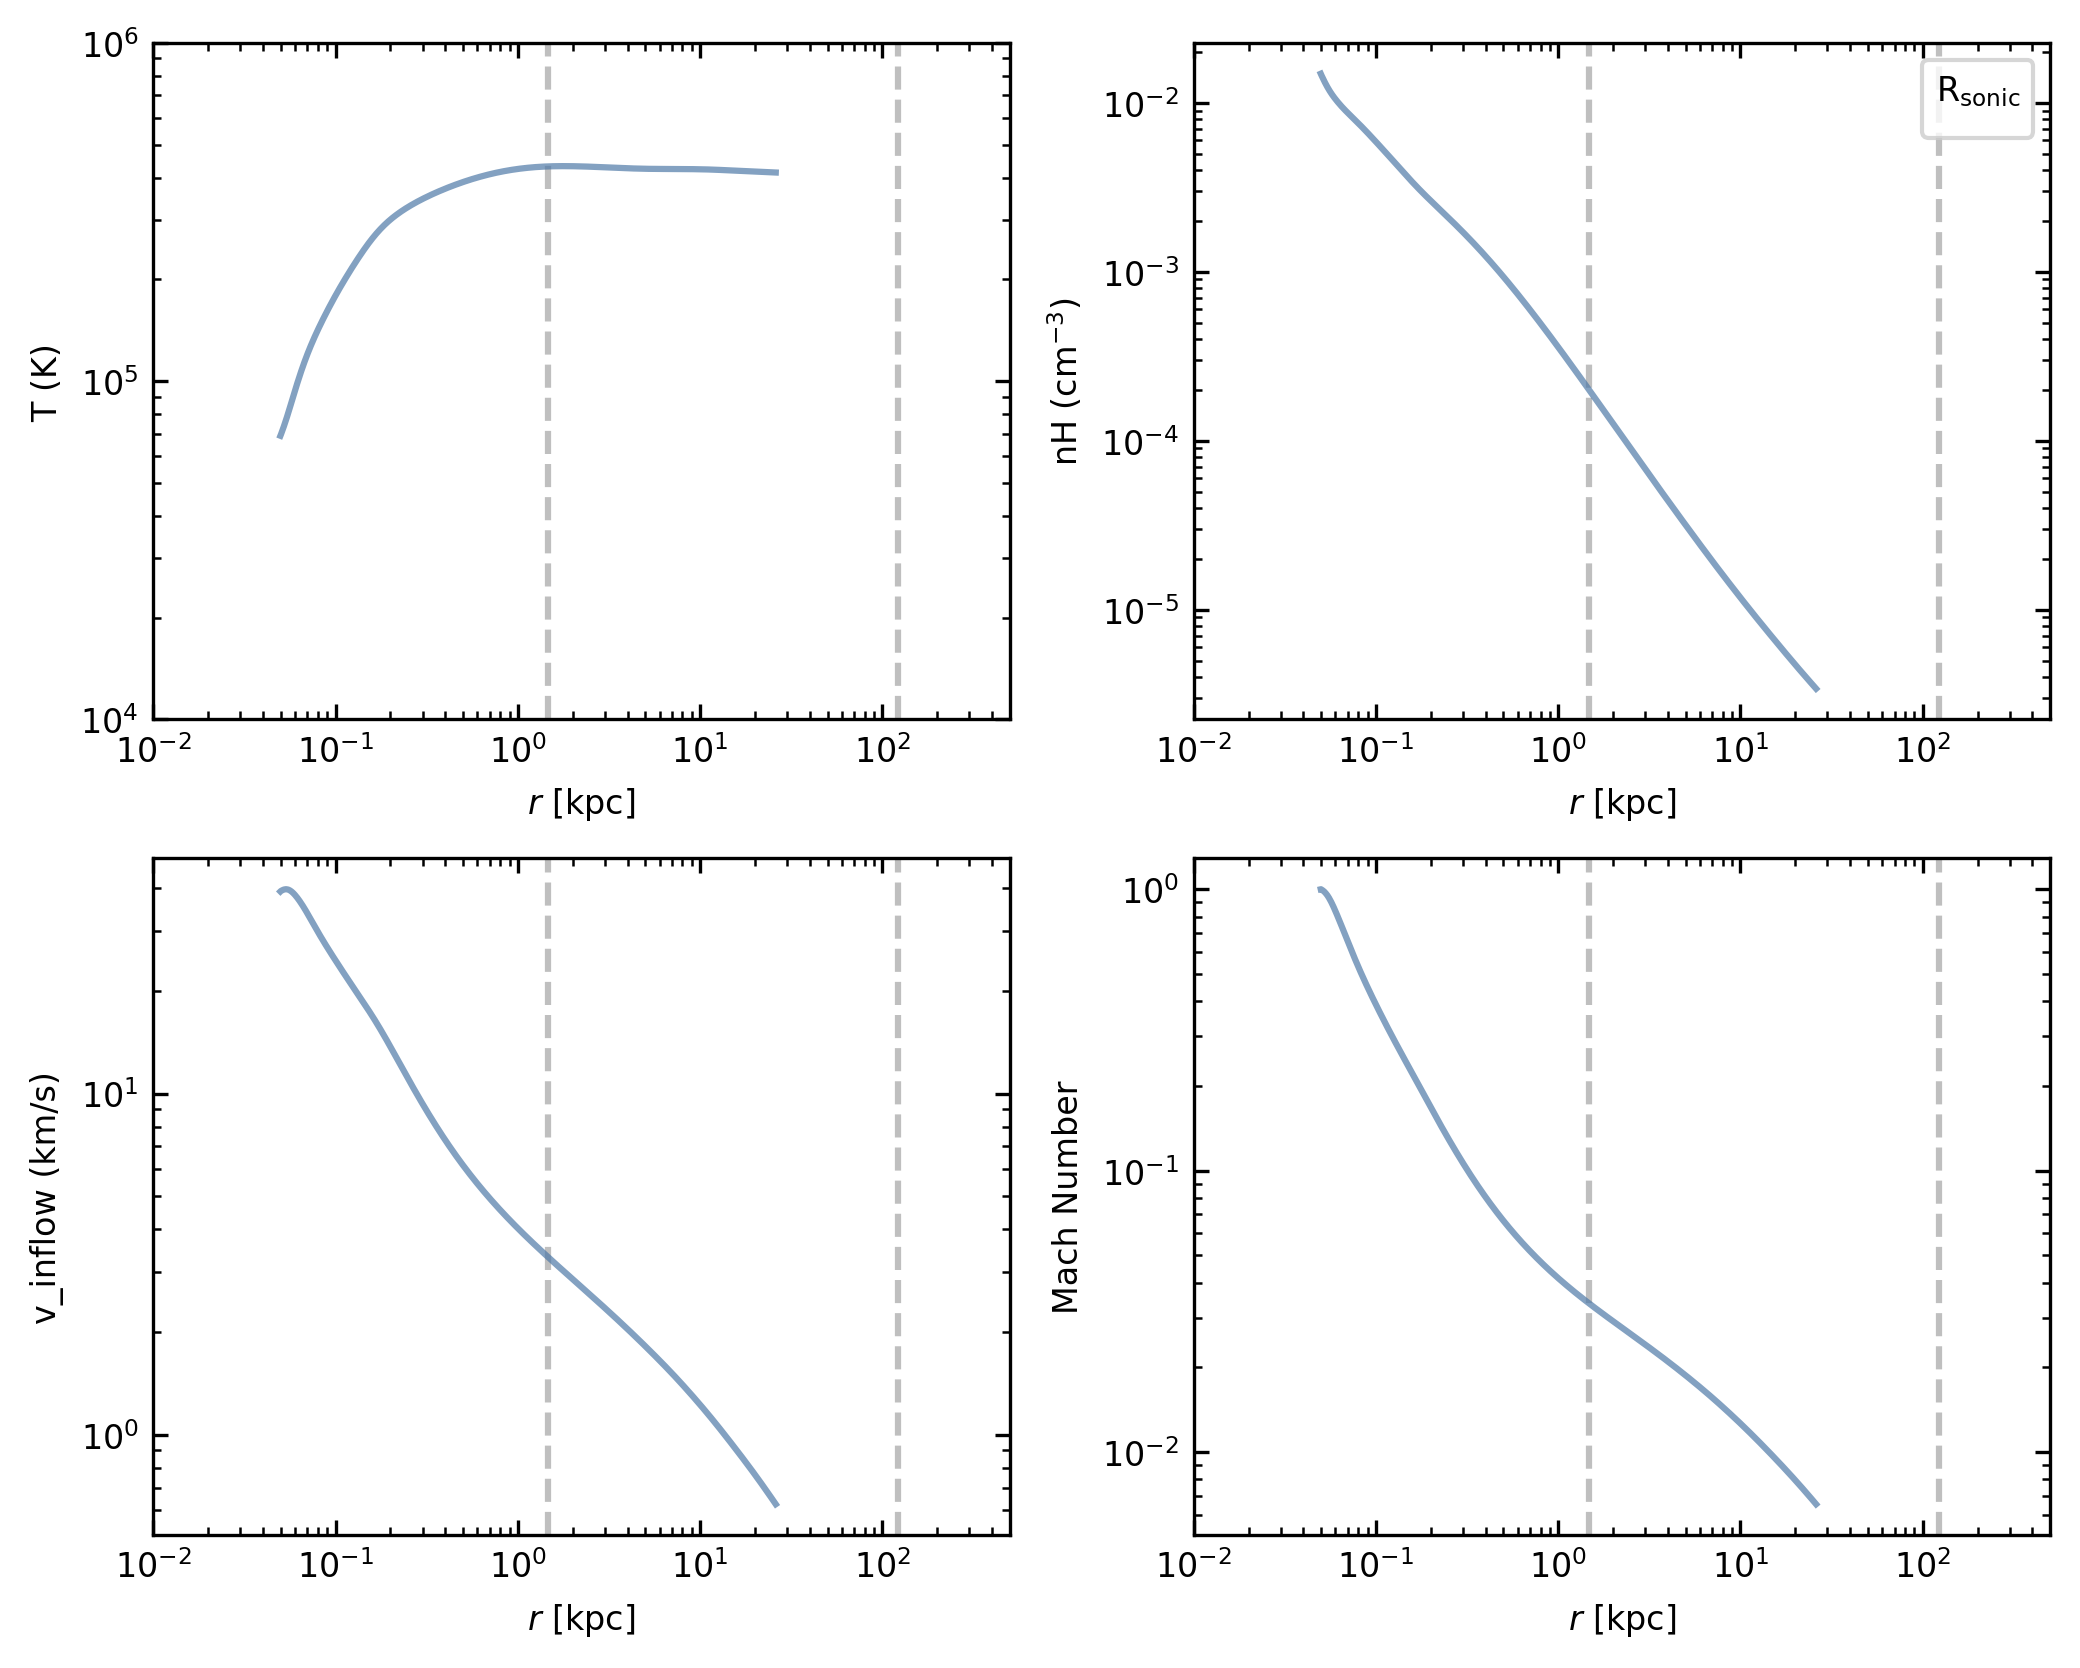

In [27]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(.01,500)

    ax.axvline(r_gal,c='.5',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='.5',ls='--',alpha=0.5)

axs[0, 0].plot(sol2.Rs, sol2.Ts, alpha=0.7)
axs[0, 0].set_ylabel(r'T (K)')
axs[0, 0].set_ylim(1e4,1e6)

axs[0, 1].plot(sol2.Rs, sol2.nHs, alpha=0.7)
axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')

axs[1, 0].plot(sol2.Rs, sol2.vs, alpha=0.7)
axs[1, 0].set_ylabel(r'v_inflow (km/s)')
    
axs[1, 1].plot(sol2.Rs, sol2.Ms, alpha=0.7)
axs[1, 1].set_ylabel(r'Mach Number')

axs[0, 1].legend(frameon=True, loc='upper right', title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

In [13]:
# Save file

"""
The file format is a header line followed by data columns:
# r T rho v
r_1 T_1 rho_1 v_1
r_2 T_2 rho_2 v_2
"""

Rs = (sol2.Rs/cu_length).to('').value
Ts = (sol2.Ts/cu_temperature).to('').value
rhos = (sol2.rhos/cu_density).to('').value
vs = (sol2.vs/cu_velocity).to('').value

# Combine arrays into a single array for saving
data = np.column_stack((Rs, Ts, rhos, vs))

# Save to file with header
header = "# r T rho v"
filename = "tables/cgm_profiles_rsonic_0.15_vertical.txt"
np.savetxt(filename, data, header=header)

print(f"Profile saved to {filename}")

Profile saved to tables/cgm_profiles_rsonic_0.15_vertical.txt
